In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1 — Install Dependencies


In [28]:
import subprocess, sys
packages = [
    'torch-geometric',
    'einops',
    'editdistance',
    'tqdm',
    'sympy',
]
subprocess.run([sys.executable, '-m', 'pip', 'install'] + packages + ['--quiet'], check=False)
import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f'Device   : {DEVICE}  dtype={DTYPE}')


PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB
Device   : cuda  dtype=torch.bfloat16


## Cell 2 — Imports


In [29]:
import os, re, math, random, pickle, json, copy, warnings
from collections import OrderedDict, Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import editdistance
from tqdm import tqdm
warnings.filterwarnings('ignore')
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR
# PyTorch Geometric
try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import GATv2Conv, global_mean_pool
    HAS_PYGEOM = True
    print('PyTorch Geometric: OK  (GATv2Conv ready)')
except ImportError:
    HAS_PYGEOM = False
    print('PyTorch Geometric: NOT FOUND — GAT encoder will fall back to feature MLP')
# SymPy
try:
    import sympy as sp
    from sympy import symbols, Rational, sympify, Poly
    HAS_SYMPY = True
    print('SymPy            : OK')
except ImportError:
    HAS_SYMPY = False
    print('SymPy            : NOT FOUND — SymPy validation disabled')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
print('Imports OK')


PyTorch Geometric: OK  (GATv2Conv ready)
SymPy            : OK
Imports OK


## Cell 3 — Vocabulary & Tokenizer


In [30]:
class AmplitudeTokenizer:

    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace
        if special_symbols is None:
            self.special_symbols = ['<PAD>','<UNK>','<BOS>','<EOS>','<SEP>','<TERM0>','<TERM1>']
        else:
            self.special_symbols = special_symbols
        self.index_pool  = [f'INDEX_{i}'  for i in range(index_pool_size)]
        self.pindex_pool = [f'PINDEX_{i}' for i in range(index_pool_size)]
        self.pat_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pat_num123   = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')
    @staticmethod
    def remove_whitespace(t): return re.sub(r'\s+', '', t)
    @staticmethod
    def split_expression(t): return re.split(r' ', t)
    def normalize_indices(self, text):
        if not self.to_replace: return text
        text = self.remove_whitespace(text)
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r's_(\d+)', r'MOMENTUM_\1', text)
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        ms = list(OrderedDict.fromkeys(self.pat_num123.findall(text)))
        it = iter(self.index_pool); mp = {}
        for m in ms:
            try: mp[m] = next(it)
            except StopIteration: raise RuntimeError('INDEX pool exhausted')
        for o, n in sorted(mp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        ps = list(OrderedDict.fromkeys(
            m.group('target') for m in sorted(
                self.pat_particle.finditer(text), key=lambda m: m.start())))
        it2 = iter(self.pindex_pool); pp = {}
        for m in ps:
            try: pp[m] = next(it2)
            except StopIteration: raise RuntimeError('PINDEX pool exhausted')
        for o, n in sorted(pp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        return text
    def tokenize_amplitude(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text)
        text = text.replace('(*)', ' CONJ ').replace('(theta_W)', '_theta_W')
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = text.replace('_PINDEX', '_ PINDEX').replace('_INDEX', '_ INDEX')
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]
    def tokenize_squared(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text).replace('(theta_W)', '_theta_W')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]
class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=None):
        if term_idx is None: term_idx = [5, 6]
        tokens = [t for t in list(tokens) if t not in special_symbols]
        self.token_list = special_symbols + tokens
        self.token_to_idx = {t: i for i, t in enumerate(self.token_list)}
        self.idx_to_token = {i: t for t, i in self.token_to_idx.items()}
        self.pad_idx = pad_idx; self.unk_idx = unk_idx
        self.bos_idx = bos_idx; self.eos_idx = eos_idx
        self.sep_idx = sep_idx; self.term_idx = term_idx
        self.special_indices = set(self.token_to_idx[s] for s in special_symbols)
    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]
    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(i, '<UNK>') for i in indices]
        return [self.idx_to_token.get(i, '<UNK>') for i in indices
                if i not in self.special_indices or i == self.sep_idx]
    def __len__(self): return len(self.token_list)
    def __getitem__(self, x):
        if isinstance(x, int): return self.idx_to_token.get(x, '<UNK>')
        return self.token_to_idx.get(x, self.unk_idx)
print('Vocabulary & Tokenizer defined.')


Vocabulary & Tokenizer defined.


## Cell 4 — Raw Data Parser
Parses the `.txt` files directly. Each line has three colon-separated fields:
1. `Interaction` string (particle labels)
2. `Diagram + Amplitude` (vertex structure, propagators, gamma matrices)
3. `Squared amplitude` (the target)


In [31]:
# ── Point these at your actual data files ─────────────────────────────────────
# If loading from processed_data.pkl (SYMBA format), see Cell 5b.
# If parsing raw .txt files directly, configure here.
# DATA_FILES = {
#     'qed': [
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-0.txt',
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-1.txt',
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-2.txt',
#     ],
#     'qcd': [
#         '/content/drive/MyDrive/Datasets/QCD-2-to-2-diag-TreeLevel-5.txt',
#         '/content/drive/MyDrive/Datasets/QCD-2-to-2-diag-TreeLevel-6.txt',
#     ],
# }
# Alternatively set PKL_PATH to load preprocessed pickle:
PKL_PATH = '/content/drive/MyDrive/SYMBA/processed_data.pkl'
def parse_raw_txt_file(filepath):

    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            # Split on the last two colons (each field may contain colons internally)
            # Fields: interaction : diagram_and_amplitude : squared
            parts = line.split(' : ')
            if len(parts) < 3: continue
            interaction = parts[0].strip()
            # Middle part contains 'Vertex ... : amplitude_expr'
            # Find where diagram ends and amplitude begins
            mid = ' : '.join(parts[1:-1])
            squared = parts[-1].strip()
            # Separate diagram topology from amplitude expression
            # Diagram ends at the last ',' before the amplitude expression
            amp_match = re.search(r':\s*(-[\d/]|i\*|[\d/])', mid)
            if amp_match:
                diagram   = mid[:amp_match.start()].strip()
                amplitude = mid[amp_match.start():].strip().lstrip(': ').strip()
            else:
                diagram   = mid
                amplitude = mid
            records.append({
                'interaction': interaction,
                'diagram'    : diagram,
                'amplitude'  : amplitude,
                'squared'    : squared,
            })
    return records
def load_and_tokenize_raw(filepaths, tokenizer, is_qcd=False):
    """
    Load raw txt files, tokenize amplitude and squared amplitude.
    Returns list of record dicts with amp_tokens and sq_tokens.
    """
    all_records = []
    for fp in filepaths:
        if not os.path.exists(fp):
            print(f'  [SKIP] {fp} not found')
            continue
        recs = parse_raw_txt_file(fp)
        for r in recs:
            r['amp_tokens'] = tokenizer.tokenize_amplitude(r['amplitude'])
            r['sq_tokens']  = tokenizer.tokenize_squared(r['squared'])
            r['is_qcd']     = is_qcd
        all_records.extend(recs)
        print(f'  Loaded {len(recs):4d} records from {os.path.basename(fp)}')
    return all_records
def build_vocabulary(records, min_freq=1):
    special = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']
    src_counter = Counter()
    tgt_counter = Counter()
    for r in records:
        src_counter.update(r['amp_tokens'])
        tgt_counter.update(r['sq_tokens'])
    src_vocab = Vocabulary(
        [t for t, c in src_counter.items() if c >= min_freq], special)
    tgt_vocab = Vocabulary(
        [t for t, c in tgt_counter.items() if c >= min_freq], special)
    return src_vocab, tgt_vocab
def train_val_test_split(records, train_ratio=0.8, val_ratio=0.1, seed=42):
    rng = random.Random(seed)
    data = records[:]
    rng.shuffle(data)
    n = len(data)
    n_tr = int(n * train_ratio)
    n_va = int(n * val_ratio)
    return data[:n_tr], data[n_tr:n_tr+n_va], data[n_tr+n_va:]
print('Raw data parser defined.')


Raw data parser defined.


## Cell 5 — Load Data (pkl OR raw txt)


In [32]:
tokenizer = AmplitudeTokenizer()
RAW_DATA  = {}
if os.path.exists(PKL_PATH):
    print(f'Loading from pickle: {PKL_PATH}')
    with open(PKL_PATH, 'rb') as f:
        PKL = pickle.load(f)
    for label in ['qed', 'qcd']:
        RAW_DATA[label.upper()] = {
            'train'    : PKL[label]['train'],
            'val'      : PKL[label]['val'],
            'test'     : PKL[label]['test'],
            'src_vocab': PKL[label]['src_vocab'],
            'tgt_vocab': PKL[label]['tgt_vocab'],
        }
        tr, va, te = len(PKL[label]['train']), len(PKL[label]['val']), len(PKL[label]['test'])
        sv, tv = len(PKL[label]['src_vocab']), len(PKL[label]['tgt_vocab'])
        print(f'  {label.upper()}: train={tr}  val={va}  test={te}  src_vocab={sv}  tgt_vocab={tv}')
else:
    print('Pickle not found. Parsing raw .txt files...')
    for label_key, filepaths in DATA_FILES.items():
        label = label_key.upper()
        is_qcd = (label == 'QCD')
        print(f'\n{label}:')
        records = load_and_tokenize_raw(filepaths, tokenizer, is_qcd=is_qcd)
        if not records:
            print(f'  [WARNING] No records found for {label}')
            continue
        tr, va, te = train_val_test_split(records)
        src_vocab, tgt_vocab = build_vocabulary(tr)
        RAW_DATA[label] = {
            'train': tr, 'val': va, 'test': te,
            'src_vocab': src_vocab, 'tgt_vocab': tgt_vocab,
        }
        print(f'  Split: train={len(tr)}  val={len(va)}  test={len(te)}')
        print(f'  Vocab: src={len(src_vocab)}  tgt={len(tgt_vocab)}')
LABELS = list(RAW_DATA.keys())
print(f'\nLabels available: {LABELS}')


Loading from pickle: /content/drive/MyDrive/SYMBA/processed_data.pkl
  QED: train=288  val=36  test=36  src_vocab=97  tgt_vocab=43
  QCD: train=187  val=23  test=24  src_vocab=179  tgt_vocab=67

Labels available: ['QED', 'QCD']


## Cell 6 — Physics-Aware Graph Parser
Converts a diagram string into a graph `G=(V,E)` where:
- Nodes = interaction vertices with particle-physics features
- Edges = propagators (off-shell particles) with their own features
- Global = scalar summary: n_vertices, n_propagators, coupling order, color, QCD flag


In [33]:
PARTICLE_PROPS = {
    'e'   : [0,  0.000511/200, 0.5, 0,  -1],
    'mu'  : [1,  0.1057/200,   0.5, 0,  -1],
    'tau' : [2,  1.777/200,    0.5, 0,  -1],
    'nu'  : [3,  0.0,          0.5, 0,   0],
    'u'   : [4,  0.0022/200,   0.5, 3,   2],
    'd'   : [5,  0.0047/200,   0.5, 3,  -1],
    's'   : [6,  0.096/200,    0.5, 3,  -1],
    'c'   : [7,  1.27/200,     0.5, 3,   2],
    'b'   : [8,  4.18/200,     0.5, 3,  -1],
    't'   : [9,  173.0/200,    0.5, 3,   2],
    'tt'  : [9,  173.0/200,    0.5, 3,   2],
    'A'   : [10, 0.0,          1.0, 0,   0],
    'G'   : [11, 0.0,          1.0, 8,   0],
    'W'   : [12, 80.4/200,     1.0, 0,   1],
    'Z'   : [13, 91.2/200,     1.0, 0,   0],
    'H'   : [14, 125.0/200,    0.0, 0,   0],
}
UNKNOWN_PROPS = [15, 0.0, 0.0, 0, 0]
NODE_FEAT_DIM  = 5
EDGE_FEAT_DIM  = 5
GLOBAL_FEAT_DIM = 7
def particle_features(pname):
    return PARTICLE_PROPS.get(pname.lower().strip().rstrip('*'), UNKNOWN_PROPS)
COLOR_FACTORS = {
    ('q', 'q', 'q', 'q')   : 4/9,
    ('q', 'qbar', 'q', 'qbar'): 4/9,
    ('q', 'qbar', 'g', 'g'): 16/9,
    ('g', 'g', 'g', 'g')   : 9,
    ('q', 'g', 'q', 'g')   : -1/6,
}
def extract_color_factor(diagram_str, is_qcd=False):
    if not is_qcd: return 1.0
    # Try to find explicit coefficient in squared amplitude
    cf_match = re.search(r'^(-?\d+/\d+|\d+)', diagram_str.strip())
    if cf_match:
        try:
            num = float(eval(cf_match.group(0)))
            return num
        except Exception:
            pass
    return 1.0
def parse_diagram_to_graph(diagram_str, is_qcd=False):

    vertex_pattern = re.compile(
        r'Vertex\s+(V_\d+):(\w+)\(X_\d+\),\s*(?:AntiPart\s+)?(\w+)\(X_\d+\),\s*'
        r'(?:OffShell\s+)?(\w+)'
    )
    vertices = vertex_pattern.findall(diagram_str)
    if not vertices:
        nf = torch.zeros(2, NODE_FEAT_DIM)
        ei = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)
        ef = torch.zeros(2, EDGE_FEAT_DIM)
        gf = torch.tensor([0, 0, 1, 0, 1, int(is_qcd), 1.0], dtype=torch.float)
        return nf, ei, ef, gf
    node_features    = []
    offshell_particles = []
    for vid, p_in, p_out, offshell in vertices:
        feat = particle_features(p_in)
        node_features.append(feat)
        offshell_particles.append(offshell)
    n = len(node_features)
    edge_index, edge_features = [], []
    for i in range(n):
        j = (i + 1) % n
        ef = particle_features(offshell_particles[i])
        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_features.append(ef)
        edge_features.append(ef)
    for i in range(n):
        edge_index.append([i, i])
        edge_features.append(node_features[i])
    nf = torch.tensor(node_features, dtype=torch.float)
    ei = torch.tensor(edge_index,    dtype=torch.long).T
    ef = torch.tensor(edge_features, dtype=torch.float)
    n_vertices    = float(n)
    n_propagators = float(len(offshell_particles))
    n_fermion_lines = sum(
        1 for p in offshell_particles
        if p.lower().rstrip('*') in ['e', 'mu', 'tau', 'u', 'd', 's', 'c', 'b', 't']
    )
    has_gluon     = float(any(p.lower() in ['g', 'G'] for p in offshell_particles))
    coupling_order = float(n)
    is_qcd_f      = float(is_qcd)
    color_factor  = 4/9 if is_qcd else 1.0
    gf = torch.tensor(
        [n_vertices, n_propagators, n_fermion_lines,
         has_gluon, coupling_order, is_qcd_f, color_factor],
        dtype=torch.float
    )
    return nf, ei, ef, gf
sample_diag = list(RAW_DATA.values())[0]['train'][0].get('diagram', '')
nf, ei, ef, gf = parse_diagram_to_graph(sample_diag, is_qcd=False)
print(f'Sample graph: nodes={nf.shape}  edges={ei.shape}  edge_feat={ef.shape}')
print(f'Global feats: {gf.tolist()}')
print('Graph parser: OK')


Sample graph: nodes=torch.Size([1, 5])  edges=torch.Size([2, 3])  edge_feat=torch.Size([3, 5])
Global feats: [1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0]
Graph parser: OK


## Cell 7 — Dataset & DataLoader


In [34]:
def recode_records(records, src_vocab, tgt_vocab, src_max, tgt_max, is_qcd=False):
    rows = []
    for r in records:
        amp_toks = list(r.get('amp_tokens', []))
        sq_toks  = list(r.get('sq_tokens',  []))
        amp_ids  = [BOS_IDX] + src_vocab.encode(amp_toks)[:src_max-2] + [EOS_IDX]
        sq_ids   = [BOS_IDX] + tgt_vocab.encode(sq_toks)[:tgt_max-2]  + [EOS_IDX]
        diag_str = r.get('diagram', '')
        nf, ei, ef, gf = parse_diagram_to_graph(diag_str, is_qcd=is_qcd)
        rows.append({
            'amp_ids'    : amp_ids,
            'sq_ids'     : sq_ids,
            'amp_tokens' : amp_toks,
            'sq_tokens'  : sq_toks,
            'node_feat'  : nf,
            'edge_index' : ei,
            'edge_feat'  : ef,
            'global_feat': gf,
            'diagram'    : diag_str,
            'squared'    : r.get('squared', ''),
            'is_qcd'     : is_qcd,
        })
    return rows
def get_max_lens(records, pct=97, cap=512):
    amp_lens = [len(r.get('amp_tokens', [])) for r in records]
    sq_lens  = [len(r.get('sq_tokens',  [])) for r in records]
    src_max  = min(int(np.percentile(amp_lens, pct)) + 4, cap)
    tgt_max  = min(int(np.percentile(sq_lens,  pct)) + 4, cap)
    return src_max, tgt_max
class PhysicsDataset(Dataset):
    def __init__(self, rows, src_max, tgt_max):
        self.rows = rows
        self.sm, self.tm = src_max, tgt_max
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows[i]
        src = torch.tensor(r['amp_ids'][:self.sm], dtype=torch.long)
        tgt = torch.tensor(r['sq_ids'][:self.tm],  dtype=torch.long)
        return {
            'src'        : src,
            'tgt'        : tgt,
            'node_feat'  : r['node_feat'],
            'edge_index' : r['edge_index'],
            'edge_feat'  : r['edge_feat'],
            'global_feat': r['global_feat'],
            'sq_tokens'  : r['sq_tokens'],
            'squared'    : r['squared'],
            'is_qcd'     : r['is_qcd'],
        }
def collate_physics(batch):
    src = pad_sequence([b['src'] for b in batch], padding_value=PAD_IDX, batch_first=True)
    tgt = pad_sequence([b['tgt'] for b in batch], padding_value=PAD_IDX, batch_first=True)
    gf  = torch.stack([b['global_feat'] for b in batch])
    if HAS_PYGEOM:
        graphs = [Data(
            x          = b['node_feat'],
            edge_index = b['edge_index'],
            edge_attr  = b['edge_feat'],
        ) for b in batch]
        graph_batch = Batch.from_data_list(graphs)
    else:
        graph_batch = None
    meta = {
        'sq_tokens': [b['sq_tokens'] for b in batch],
        'squared'  : [b['squared']   for b in batch],
        'is_qcd'   : [b['is_qcd']    for b in batch],
    }
    return src, tgt, graph_batch, gf, meta
DATASETS = {}
for label in LABELS:
    sv     = RAW_DATA[label]['src_vocab']
    tv     = RAW_DATA[label]['tgt_vocab']
    is_qcd = (label == 'QCD')
    src_max, tgt_max = get_max_lens(RAW_DATA[label]['train'])
    tr_rows = recode_records(RAW_DATA[label]['train'], sv, tv, src_max, tgt_max, is_qcd)
    va_rows = recode_records(RAW_DATA[label]['val'],   sv, tv, src_max, tgt_max, is_qcd)
    te_rows = recode_records(RAW_DATA[label]['test'],  sv, tv, src_max, tgt_max, is_qcd)
    DATASETS[label] = {
        'train'    : PhysicsDataset(tr_rows, src_max, tgt_max),
        'val'      : PhysicsDataset(va_rows, src_max, tgt_max),
        'test'     : PhysicsDataset(te_rows, src_max, tgt_max),
        'src_vocab': sv,
        'tgt_vocab': tv,
        'src_max'  : src_max,
        'tgt_max'  : tgt_max,
    }
    print(f'{label}: train={len(tr_rows)}  val={len(va_rows)}  test={len(te_rows)}  '
          f'src_max={src_max}  tgt_max={tgt_max}  '
          f'src_vocab={len(sv)}  tgt_vocab={len(tv)}')
print('Datasets built.')


QED: train=288  val=36  test=36  src_max=183  tgt_max=128  src_vocab=97  tgt_vocab=43
QCD: train=187  val=23  test=24  src_max=512  tgt_max=512  src_vocab=179  tgt_vocab=67
Datasets built.


## Cell 8 — SymPy Validation Layer
Validates generated squared amplitudes symbolically using SymPy:
1. Mass dimension check : |M|² must be dimensionless in natural units
2. Non-negativity: |M|² ≥ 0 at physical points
3. Coupling power: coefficient must be coupling^(2·n_vertices)
4. Mandelstam completeness: only s₁₂,s₁₃,s₁₄,s₂₃,s₂₄,s₃₄ and masses allowed
5. Color factor: QCD expressions must have correct SU(3) prefactor


In [35]:

HAS_SYMPY = False
try:
    import sympy as sp
    from sympy import symbols, sympify, Poly
    HAS_SYMPY = True
except ImportError:
    pass

if HAS_SYMPY:
    _s12, _s13, _s14, _s23, _s24, _s34 = sp.symbols(
        's_12 s_13 s_14 s_23 s_24 s_34', real=True)
    _m_e, _m_mu, _m_tau = sp.symbols('m_e m_mu m_tau', positive=True)
    _m_u, _m_d, _m_s    = sp.symbols('m_u m_d m_s',   positive=True)
    _m_c, _m_b, _m_t    = sp.symbols('m_c m_b m_t',   positive=True)
    _m_tt               = sp.symbols('m_tt',            positive=True)
    _e, _g              = sp.symbols('e g',             positive=True)
    _reg_prop           = sp.symbols('reg_prop',        positive=True)

    ALLOWED_SYMBOLS = {
        _s12, _s13, _s14, _s23, _s24, _s34,
        _m_e, _m_mu, _m_tau, _m_u, _m_d, _m_s,
        _m_c, _m_b, _m_t, _m_tt, _e, _g, _reg_prop
    }


    _LOCALS_MAP = {
        's_12': _s12, 's_13': _s13, 's_14': _s14,
        's_23': _s23, 's_24': _s24, 's_34': _s34,
        'm_e': _m_e,  'm_mu': _m_mu,  'm_tau': _m_tau,
        'm_u': _m_u,  'm_d': _m_d,    'm_s': _m_s,
        'm_c': _m_c,  'm_b': _m_b,    'm_t': _m_t,   'm_tt': _m_tt,
        'e': _e,  'g': _g,  'reg_prop': _reg_prop,
        'i': 1,
        **{f'idx{i}':  sp.Symbol(f'idx{i}',  positive=True) for i in range(500)},
        **{f'pidx{i}': sp.Symbol(f'pidx{i}', positive=True) for i in range(500)},
        **{f'mom{i}':  sp.Symbol(f'mom{i}',  positive=True) for i in range(50)},
    }

    _SUBS_TEMPLATE = {
        _s12: 10.0, _s34: 10.0,
        _s13: -3.0, _s24: -3.0,
        _s14: -3.0, _s23: -3.0,
        _m_e: 1.0, _m_mu: 1.0, _m_tau: 1.0,
        _m_u: 1.0, _m_d:  1.0, _m_s:   1.0,
        _m_c: 1.0, _m_b:  1.0, _m_t:   1.0, _m_tt: 1.0,
        _e:   0.303, _g: 1.0, _reg_prop: 0.001,
    }


def tokens_to_sympy_string(tokens):
    import re as _re
    text = ' '.join(tokens)
    for s in ['<BOS>', '<EOS>', '<PAD>', '<UNK>', '<SEP>', '<TERM0>', '<TERM1>']:
        text = text.replace(s, '')
    for i in range(500):
        text = text.replace(f'PINDEX_{i}', f'pidx{i}')
        text = text.replace(f'INDEX_{i}',  f'idx{i}')
    text = _re.sub(r'MOMENTUM_(\d+)', r'mom\1', text)
    text = _re.sub(r'\s+', '', text)
    text = text.replace('^', '**')
    return text.strip()


def validate_squared_amplitude(token_list, global_feat_vec, is_qcd=False):

    if not HAS_SYMPY:
        return {'valid': True, 'violations': [], 'n_violations': 0, 'penalty': 0.0}

    violations = []

    expr_str = tokens_to_sympy_string(token_list)
    if not expr_str:
        return {'valid': False, 'violations': ['empty_expression'],
                'n_violations': 1, 'penalty': 1.0}

    try:
        expr = sp.sympify(expr_str, locals=_LOCALS_MAP)
    except Exception as ex:
        return {'valid': False, 'violations': [f'parse_error: {ex}'],
                'n_violations': 1, 'penalty': 1.0}

    idx_syms = {v for k, v in _LOCALS_MAP.items()
                if k.startswith(('idx', 'pidx', 'mom'))}
    forbidden = expr.free_symbols - ALLOWED_SYMBOLS - idx_syms
    if forbidden:
        violations.append(f'forbidden_symbols={[str(s) for s in forbidden]}')

    if global_feat_vec is not None:
        n_verts      = int(float(global_feat_vec[0]))
        expected_pow = 2 * n_verts
        coupling     = _g if is_qcd else _e
        try:
            actual_pow = sp.Poly(expr, coupling).degree() \
                         if expr.has(coupling) else 0
            if actual_pow != expected_pow:
                violations.append(
                    f'coupling_power={actual_pow} (expected {expected_pow})')
        except Exception:
            pass

    try:
        val = complex(expr.subs(_SUBS_TEMPLATE))
        if abs(val.imag) > 1e-4:
            violations.append(f'imaginary_part={val.imag:.3e}')
    except Exception:

    n_v = len(violations)
    return {
        'valid':        n_v == 0,
        'violations':   violations,
        'n_violations': n_v,
        'penalty':      min(1.0, n_v / 3.0),
    }


print('SymPy validation layer defined.')
if HAS_SYMPY:
    _test = ['1', '/', '4', '*', 'e', '^', '4', '*', '(',
             '8', '*', 's_14', '*', 's_23', '+', '8', '*', 's_13', '*', 's_24',
             ')', '*', '(', 'm_e', '^', '2', '+', 's_12', ')', '^', '(', '-', '2', ')']
    _r = validate_squared_amplitude(_test, [2,2,0,0,2,0,1.0], is_qcd=False)
    print(f'  QED self-test : valid={_r["valid"]}  violations={_r["violations"]}')
    _test2 = ['-','1','/','144','*','g','^','4','*','(',
              '(','-','16',')','*','m_b','^','2','*','m_u','^','2',
              '+','(','-','8',')','*','m_u','^','2','*','s_12',
              ')','*','(','m_b','^','2','+','s_12',')','^','(','-','2',')']
    _r2 = validate_squared_amplitude(_test2, [2,2,0,1,2,1,4/9], is_qcd=True)
    print(f'  QCD self-test : valid={_r2["valid"]}  violations={_r2["violations"]}')


SymPy validation layer defined.
  QED self-test : valid=True  violations=[]
  QCD self-test : valid=True  violations=[]


## Cell 9 — Model Configuration


In [36]:
CFG = {
    # Model dimensions
    'dim'              : 128,
    'num_heads'        : 8,
    'head_dim'         : 16,
    'ffn_dim'          : 512,
    'num_enc_layers'   : 4,
    'num_dec_layers'   : 4,

    # GAT graph encoder (GATv2Conv)
    'gnn_hidden'       : 64,
    'gnn_layers'       : 3,
    'gnn_heads'        : 4,
    'gnn_dropout'      : 0.1,
    'node_feat_dim'    : NODE_FEAT_DIM,
    'edge_feat_dim'    : EDGE_FEAT_DIM,
    'global_feat_dim'  : GLOBAL_FEAT_DIM,

    # Positional encoding
    'max_seq_len'      : 600,
    'use_rope'         : True,
    'init_std'         : 0.02,

    # Regularisation
    'dropout'          : 0.10,
    'label_smoothing'  : 0.05,

    # Training — single full run per label
    'batch_size'       : 8,
    'grad_accum'       : 4,
    'epochs'           : 100,
    'lr'               : 3e-4,
    'end_lr'           : 1e-6,
    'weight_decay'     : 1e-4,
    'warmup_ratio'     : 0.10,
    'clip_grad'        : 1.0,


}

CKPT_DIR = './ckpt_gat_symba'
EVAL_DIR = './eval_gat_symba'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)
print('Config ready.')
print(f'  Epochs={CFG["epochs"]}  eff_batch={CFG["batch_size"]*CFG["grad_accum"]}'
      f'  lr={CFG["lr"]}  label_smooth={CFG["label_smoothing"]}')
print('  Training loss: CE only (physics constraints at eval time via SymPy)')


Config ready.
  Epochs=100  eff_batch=32  lr=0.0003  label_smooth=0.05
  Training loss: CE only (physics constraints at eval time via SymPy)


## Cell 10 — Building Blocks (RoPE, RMSNorm, FFN)


In [37]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / (x.pow(2).mean(-1, keepdim=True) + self.eps).sqrt() * self.weight
class RoPEEmbedding(nn.Module):
    def __init__(self, head_dim, max_seq=2048):
        super().__init__()
        inv = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer('inv_freq', inv)
        self._build(max_seq)
    def _build(self, L, device=None, dtype=None):
        inv = self.inv_freq.to(device) if device else self.inv_freq
        pos = torch.arange(L, device=inv.device, dtype=torch.float32)
        f   = torch.outer(pos, inv.float())
        cos, sin = f.cos(), f.sin()
        if dtype: cos, sin = cos.to(dtype), sin.to(dtype)
        self.register_buffer('cos_c', cos, persistent=False)
        self.register_buffer('sin_c', sin, persistent=False)
    def forward(self, q, k):
        S = q.shape[2]
        if S > self.cos_c.shape[0] or self.cos_c.device != q.device:
            self._build(max(S, self.cos_c.shape[0]), q.device, q.dtype)
        cos = self.cos_c[:S].unsqueeze(0).unsqueeze(0)
        sin = self.sin_c[:S].unsqueeze(0).unsqueeze(0)
        def rot(x):
            x1, x2 = x[..., ::2], x[..., 1::2]
            return torch.stack([x1*cos - x2*sin, x1*sin + x2*cos], -1).flatten(-2)
        return rot(q), rot(k)
class SwiGLUFFN(nn.Module):
    def __init__(self, dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.gate = nn.Linear(dim, ffn_dim, bias=False)
        self.up   = nn.Linear(dim, ffn_dim, bias=False)
        self.down = nn.Linear(ffn_dim, dim, bias=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        return self.down(self.drop(F.silu(self.gate(x)) * self.up(x)))
print('Building blocks defined.')


Building blocks defined.


## Cell 11 — GAT Graph Encoder (GATv2Conv)



In [38]:
class GATGraphEncoder(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.use_pygeom = HAS_PYGEOM
        in_dim   = cfg['node_feat_dim']    # 5
        h_dim    = cfg['gnn_hidden']       # 64
        out_dim  = cfg['dim']              # 128
        heads    = cfg['gnn_heads']        # 4
        edge_dim = cfg['edge_feat_dim']    # 5
        dropout  = cfg['gnn_dropout']      # 0.1
        self.input_proj = nn.Linear(in_dim, h_dim)
        self.edge_proj  = nn.Linear(edge_dim, h_dim)
        if self.use_pygeom:
            self.gat1 = GATv2Conv(
                in_channels  = h_dim,
                out_channels = h_dim,
                heads        = heads,
                concat       = True,
                dropout      = dropout,
                edge_dim     = h_dim,
                add_self_loops = True,
            )
            self.norm1 = nn.LayerNorm(h_dim * heads)
            self.gat2 = GATv2Conv(
                in_channels  = h_dim * heads,
                out_channels = h_dim,
                heads        = heads,
                concat       = True,
                dropout      = dropout,
                edge_dim     = h_dim,
                add_self_loops = True,
            )
            self.norm2 = nn.LayerNorm(h_dim * heads)
            self.gat3 = GATv2Conv(
                in_channels  = h_dim * heads,
                out_channels = out_dim,
                heads        = 1,
                concat       = False,
                dropout      = dropout,
                edge_dim     = h_dim,
                add_self_loops = True,
            )
            self.norm3 = nn.LayerNorm(out_dim)
        else:
            self.fallback = nn.Sequential(
                nn.Linear(cfg['global_feat_dim'] + in_dim, h_dim), nn.SiLU(),
                nn.LayerNorm(h_dim),
                nn.Linear(h_dim, out_dim),
            )
        self.global_proj = nn.Linear(cfg['global_feat_dim'], out_dim)
        self.fusion_norm = nn.LayerNorm(out_dim)
        self.fusion_gate = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim), nn.Sigmoid()
        )
        self.act     = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
    def forward(self, graph_batch, global_feats):

        B = global_feats.shape[0]
        g_proj = self.global_proj(global_feats)
        if self.use_pygeom and graph_batch is not None:
            x  = self.input_proj(graph_batch.x.to(global_feats.device))
            ei = graph_batch.edge_index.to(global_feats.device)
            ea = self.edge_proj(graph_batch.edge_attr.to(global_feats.device))
            bv = graph_batch.batch.to(global_feats.device)
            # Layer 1
            x = self.act(self.norm1(self.gat1(x, ei, edge_attr=ea)))
            x = self.dropout(x)
            # Layer 2
            x = self.act(self.norm2(self.gat2(x, ei, edge_attr=ea)))
            x = self.dropout(x)
            # Layer 3 → output dim
            x = self.norm3(self.gat3(x, ei, edge_attr=ea))
            # Global mean pooling over all nodes in each graph
            x_pooled = global_mean_pool(x, bv)
        else:
            x_pooled = g_proj  # fallback
        # Gated fusion
        gate = self.fusion_gate(torch.cat([x_pooled, g_proj], dim=-1))  # (B, out_dim)
        out  = self.fusion_norm(gate * x_pooled + (1 - gate) * g_proj)  # (B, out_dim)
        return out
print('GATGraphEncoder defined.')


GATGraphEncoder defined.


## Cell 12 — Transformer Encoder for Amplitude Text


In [39]:
class AmplitudeTransformerEncoder(nn.Module):

    def __init__(self, cfg, vocab_size):
        super().__init__()
        d          = cfg['dim']
        n_heads    = cfg['num_heads']
        ffn_dim    = cfg['ffn_dim']
        dropout    = cfg['dropout']
        n_layers   = cfg['num_enc_layers']
        max_seq    = cfg['max_seq_len']
        self.embed   = nn.Embedding(vocab_size, d, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_seq, d)
        nn.init.normal_(self.embed.weight,   std=cfg['init_std'])
        nn.init.normal_(self.pos_emb.weight, std=cfg['init_std'])
        enc_layer = nn.TransformerEncoderLayer(
            d_model        = d,
            nhead          = n_heads,
            dim_feedforward= ffn_dim,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,
            activation     = 'gelu',
        )
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.out_norm = nn.LayerNorm(d)
        self.dropout  = nn.Dropout(dropout)
    def forward(self, src, src_key_padding_mask=None):

        B, S = src.shape
        positions = torch.arange(S, device=src.device).unsqueeze(0).expand(B, -1)
        x = self.dropout(self.embed(src) + self.pos_emb(positions))
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        return self.out_norm(x)   # (B, S, dim)
print('AmplitudeTransformerEncoder defined.')


AmplitudeTransformerEncoder defined.


## Cell 13 — Transformer Decoder for Squared Amplitude


In [40]:
class SquaredAmplitudeDecoder(nn.Module):

    def __init__(self, cfg, tgt_vocab_size):
        super().__init__()
        d         = cfg['dim']
        n_heads   = cfg['num_heads']
        ffn_dim   = cfg['ffn_dim']
        dropout   = cfg['dropout']
        n_layers  = cfg['num_dec_layers']
        max_seq   = cfg['max_seq_len']
        self.embed   = nn.Embedding(tgt_vocab_size, d, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_seq, d)
        nn.init.normal_(self.embed.weight,   std=cfg['init_std'])
        nn.init.normal_(self.pos_emb.weight, std=cfg['init_std'])
        dec_layer = nn.TransformerDecoderLayer(
            d_model        = d,
            nhead          = n_heads,
            dim_feedforward= ffn_dim,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,   # pre-norm
            activation     = 'gelu',
        )
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.out_norm = nn.LayerNorm(d)
        self.head     = nn.Linear(d, tgt_vocab_size, bias=False)
        # Weight tying
        self.head.weight = self.embed.weight
        self.dropout  = nn.Dropout(dropout)
    def forward(self, tgt, memory,
                tgt_key_padding_mask=None,
                memory_key_padding_mask=None):

        B, T  = tgt.shape
        positions = torch.arange(T, device=tgt.device).unsqueeze(0).expand(B, -1)
        x = self.dropout(self.embed(tgt) + self.pos_emb(positions))
        # Causal mask prevents attending to future tokens
        causal_mask = torch.triu(
            torch.ones(T, T, device=tgt.device), diagonal=1
        ).bool()
        out = self.decoder(
            tgt              = x,
            memory           = memory,
            tgt_mask         = causal_mask,
            tgt_key_padding_mask    = tgt_key_padding_mask,
            memory_key_padding_mask = memory_key_padding_mask,
        )
        return self.head(self.out_norm(out))
print('SquaredAmplitudeDecoder defined.')


SquaredAmplitudeDecoder defined.


## Cell 14 — Full Physics-Informed Model


In [41]:
class PhysicsInformedSYMBA(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        d = cfg['dim']
        if cfg.get('use_gat', True):
            self.gat_encoder = GATGraphEncoder(cfg)
        if cfg.get('use_amp_encoder', True):
            self.amp_encoder = AmplitudeTransformerEncoder(cfg, cfg['src_vocab_size'])
        if cfg.get('use_physics_feats', True):
            self.physics_mlp = nn.Sequential(
                nn.Linear(cfg['global_feat_dim'], d), nn.SiLU(),
                nn.LayerNorm(d),
                nn.Linear(d, d),
            )
        self.fallback_emb = nn.Sequential(
            nn.Embedding(cfg['src_vocab_size'], d, padding_idx=PAD_IDX),
            nn.LayerNorm(d),
        )
        self.decoder = SquaredAmplitudeDecoder(cfg, cfg['tgt_vocab_size'])
    def build_memory(self, src, graph_batch, global_feats, src_pad_mask):

        B = src.shape[0]
        side_tokens = []
        if self.cfg.get('use_gat', True):
            gat_emb = self.gat_encoder(graph_batch, global_feats)
            side_tokens.append(gat_emb.unsqueeze(1))
        if self.cfg.get('use_physics_feats', True):
            phys_emb = self.physics_mlp(global_feats)
            side_tokens.append(phys_emb.unsqueeze(1))
        if self.cfg.get('use_amp_encoder', True):
            src_padding_mask = (src == PAD_IDX)
            amp_enc = self.amp_encoder(src, src_key_padding_mask=src_padding_mask)
        else:
            amp_enc = self.fallback_emb[0](src)
            amp_enc = self.fallback_emb[1](amp_enc)
        if side_tokens:
            side = torch.cat(side_tokens, dim=1)        #
            memory = torch.cat([side, amp_enc], dim=1)
            side_mask = torch.ones(B, side.shape[1], dtype=torch.bool, device=src.device)
        else:
            memory    = amp_enc
            side_mask = torch.zeros(B, 0, dtype=torch.bool, device=src.device)
        amp_real_mask = (src != PAD_IDX)
        mem_real_mask = torch.cat([side_mask, amp_real_mask], dim=1)
        return memory, mem_real_mask
    def forward(self, src, tgt, graph_batch, global_feats):

        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt == PAD_IDX)
        memory, mem_real_mask = self.build_memory(
            src, graph_batch, global_feats, src_pad_mask
        )
        logits = self.decoder(
            tgt                     = tgt,
            memory                  = memory,
            tgt_key_padding_mask    = tgt_pad_mask,
            memory_key_padding_mask = ~mem_real_mask,
        )
        return logits
    @torch.no_grad()
    def greedy_decode(self, src, graph_batch, global_feats, max_len=200):
        self.eval()
        B = src.shape[0]
        src_pad_mask = (src == PAD_IDX)
        memory, mem_real_mask = self.build_memory(
            src, graph_batch, global_feats, src_pad_mask
        )
        ys   = torch.full((B, 1), BOS_IDX, dtype=torch.long, device=src.device)
        done = torch.zeros(B, dtype=torch.bool, device=src.device)
        for _ in range(max_len - 1):
            logits   = self.decoder(tgt=ys, memory=memory,
                                    memory_key_padding_mask=~mem_real_mask)
            next_tok = logits[:, -1, :].argmax(-1)
            done    |= (next_tok == EOS_IDX)
            ys       = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            if done.all(): break
        return ys
print('PhysicsInformedSYMBA defined.')


PhysicsInformedSYMBA defined.


## Cell 15 — Physics Loss Functions




In [42]:

QCD_COLOR_FACTORS = {
    (2, False): 4.0/9,
    (1, True) : 1.0/6,
    (0, True) : 9.0,
    (2, True) : 16.0/27,
}


def check_coupling_power(pred_toks, n_vertices, is_qcd, tgt_vocab):

    expected = int(n_vertices) * 2
    coupling_tok = 'g' if is_qcd else 'e'
    for i in range(len(pred_toks) - 2):
        if pred_toks[i] == coupling_tok and pred_toks[i+1] == '^':
            try:
                pred_pow = int(pred_toks[i+2])
                return pred_pow, expected, (pred_pow == expected)
            except (ValueError, TypeError):
                return None, expected, False
    return None, expected, False


def _extract_leading_coeff(toks):

    window = toks[:15]
    for i in range(len(window) - 2):
        if window[i + 1] == '/':
            try:
                num = float(window[i])
                den = float(window[i + 2])
                if den == 0:
                    continue
                cf = num / den
                # Absorb a preceding minus sign that is a separate token
                if i > 0 and window[i - 1] == '-':
                    cf = -cf
                return cf
            except (ValueError, TypeError):
                continue
    # Fallback: first token that is a plain number
    for tok in window:
        if tok in ('/', '*', '+', '-', '^', '(', ')', 'g', 'e', 'i'):
            continue
        try:
            return float(tok)
        except (ValueError, TypeError):
            continue
    return None


def check_color_factor(pred_toks, ref_toks, is_qcd):

    if not is_qcd:
        return None, None, None

    pred_cf = _extract_leading_coeff(pred_toks)
    ref_cf  = _extract_leading_coeff(ref_toks)

    if pred_cf is None or ref_cf is None:
        return pred_cf, ref_cf, False

    is_correct = abs(pred_cf - ref_cf) / max(abs(ref_cf), 1e-9) < 0.05
    return pred_cf, ref_cf, is_correct

## Cell 16 — Model Builder & Parameter Count


In [43]:
def build_model(label, ablation_cfg=None):

    sv = DATASETS[label]['src_vocab']
    tv = DATASETS[label]['tgt_vocab']
    cfg = copy.deepcopy(CFG)
    cfg['src_vocab_size'] = len(sv)
    cfg['tgt_vocab_size'] = len(tv)
    if ablation_cfg:
        cfg.update(ablation_cfg)
    model = PhysicsInformedSYMBA(cfg).to(DEVICE)
    return model, cfg
# ── Parameter count ───────────────────────────────────────────────────────────
print('Model parameter counts (full model):')
for label in LABELS:
    m, _ = build_model(label)
    total      = sum(p.numel() for p in m.parameters())
    trainable  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {label}: total={total:,} ({total/1e6:.2f}M)  trainable={trainable:,}')
    del m
    torch.cuda.empty_cache()
print('Model builder: OK')


Model parameter counts (full model):
  QED: total=2,363,008 (2.36M)  trainable=2,363,008
  QCD: total=2,387,072 (2.39M)  trainable=2,387,072
Model builder: OK


## Cell 17 — Training Loop


In [44]:
def train_model(label, run_name, ablation_flags=None, n_epochs=None, lr=None):

    n_epochs = n_epochs or CFG['epochs']
    lr       = lr       or CFG['lr']
    accum    = CFG['grad_accum']
    batch_sz = CFG['batch_size']

    tv     = DATASETS[label]['tgt_vocab']
    tgt_vs = len(tv)

    model, run_cfg = build_model(label, ablation_flags)

    dl_tr = DataLoader(
        DATASETS[label]['train'], batch_size=batch_sz, shuffle=True,
        collate_fn=collate_physics, num_workers=2, pin_memory=True, drop_last=True
    )
    dl_va = DataLoader(
        DATASETS[label]['val'], batch_size=batch_sz, shuffle=False,
        collate_fn=collate_physics, num_workers=2, pin_memory=True
    )

    # Single CE loss
    crit     = nn.CrossEntropyLoss(ignore_index=PAD_IDX,
                                    label_smoothing=CFG['label_smoothing'])
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')

    opt = torch.optim.AdamW(
        model.parameters(), lr=lr,
        weight_decay=CFG['weight_decay'], eps=1e-9
    )
    scaler = GradScaler()

    total_steps = (len(dl_tr) // accum) * n_epochs
    warm_steps  = max(1, int(CFG['warmup_ratio'] * total_steps))

    def lr_lambda(step):
        if step < warm_steps:
            return max(1e-8, step / warm_steps)
        p = (step - warm_steps) / max(1, total_steps - warm_steps)
        return max(CFG['end_lr'] / lr, 0.5 * (1 + math.cos(math.pi * p)))

    sched     = LambdaLR(opt, lr_lambda)
    save_dir  = os.path.join(CKPT_DIR, run_name)
    os.makedirs(save_dir, exist_ok=True)
    ckpt_path = os.path.join(save_dir, f'{label}_best.pth')

    history = {
        'tr_loss': [], 'tr_ppl': [],
        'va_loss': [], 'va_ppl': [], 'va_tok_acc': [],
    }
    best_va = float('inf')
    gs      = 0

    print(f'\n{"="*70}')
    print(f'  Run   : {run_name} | Label : {label}')
    print(f'  Loss  : CrossEntropyLoss only (label_smooth={CFG["label_smoothing"]})')
    print(f'  Train : {len(dl_tr.dataset)}  Val : {len(dl_va.dataset)}')
    print(f'  Epochs: {n_epochs}  eff_batch={batch_sz*accum}  lr={lr}')
    print(f'{"="*70}')
    print(f'  {"ep":>5}  {"tr_loss":>9}  {"tr_ppl":>8}  {"va_loss":>9}  {"va_ppl":>8}  {"tok_acc":>8}')
    print(f'  {"-"*65}')

    try:
        for ep in range(n_epochs):
            model.train()
            tl, tn, tkl, tkn = 0., 0, 0., 0
            opt.zero_grad()

            for si, (src, tgt, graph_b, gf, _meta) in enumerate(dl_tr):
                src = src.to(DEVICE); tgt = tgt.to(DEVICE); gf = gf.to(DEVICE)
                if graph_b is not None: graph_b = graph_b.to(DEVICE)

                tgt_in  = tgt[:, :-1]  # input to decoder (BOS … last-1)
                tgt_out = tgt[:, 1:]   # teacher-forced targets (first+1 … EOS)

                with autocast(
                    device_type='cuda' if DEVICE.type == 'cuda' else 'cpu',
                    dtype=DTYPE
                ):
                    logits = model(src, tgt_in, graph_b, gf)  # (B, T, V)
                    loss   = crit(
                        logits.reshape(-1, tgt_vs),
                        tgt_out.reshape(-1)
                    ) / accum

                scaler.scale(loss).backward()

                if (si + 1) % accum == 0:
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), CFG['clip_grad'])
                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad()
                    sched.step()
                    gs += 1

                with torch.no_grad():
                    tkl += crit_sum(
                        logits.reshape(-1, tgt_vs), tgt_out.reshape(-1)
                    ).item()
                    tkn += (tgt_out != PAD_IDX).sum().item()
                tl += loss.item() * accum * src.size(0)
                tn += src.size(0)

            tr_loss = tl / max(tn, 1)
            tr_ppl  = math.exp(min(tkl / max(tkn, 1), 20))

            # ── Validation ────────────────────────────────────────────────
            model.eval()
            vl, vn, vc, vt, vkl, vkn = 0., 0, 0, 0, 0., 0
            with torch.no_grad():
                for src_v, tgt_v, graph_bv, gf_v, _ in dl_va:
                    src_v = src_v.to(DEVICE)
                    tgt_v = tgt_v.to(DEVICE)
                    gf_v  = gf_v.to(DEVICE)
                    if graph_bv is not None: graph_bv = graph_bv.to(DEVICE)
                    ti_v = tgt_v[:, :-1]; to_v = tgt_v[:, 1:]
                    lg_v = model(src_v, ti_v, graph_bv, gf_v)
                    vkl += crit_sum(
                        lg_v.reshape(-1, tgt_vs), to_v.reshape(-1)
                    ).item()
                    vkn += (to_v != PAD_IDX).sum().item()
                    msk  = (to_v != PAD_IDX)
                    vc  += (lg_v.argmax(-1) == to_v).masked_select(msk).sum().item()
                    vt  += msk.sum().item()
                    lv   = crit(lg_v.reshape(-1, tgt_vs), to_v.reshape(-1))
                    vl  += lv.item() * src_v.size(0)
                    vn  += src_v.size(0)

            va_loss = vl / max(vn, 1)
            va_ppl  = math.exp(min(vkl / max(vkn, 1), 20))
            va_acc  = vc / max(vt, 1)

            history['tr_loss'].append(tr_loss)
            history['tr_ppl'].append(tr_ppl)
            history['va_loss'].append(va_loss)
            history['va_ppl'].append(va_ppl)
            history['va_tok_acc'].append(va_acc)

            if va_loss < best_va:
                best_va = va_loss
                torch.save({
                    'model'          : model.state_dict(),
                    'va_loss'        : va_loss,
                    'va_ppl'         : va_ppl,
                    'history'        : history,
                    'label'          : label,
                    'cfg'            : run_cfg,
                    'epoch'          : ep,
                }, ckpt_path)

            if (ep + 1) % 10 == 0 or ep == 0:
                star = ' ★' if va_loss == best_va else ''
                print(
                    f'  {ep+1:5d}  {tr_loss:9.4f}  {tr_ppl:8.3f}  '
                    f'{va_loss:9.4f}  {va_ppl:8.3f}  {va_acc*100:7.2f}%{star}'
                )

    except KeyboardInterrupt:
        print('\n  [Interrupted by user]')
    except Exception as e:
        print(f'  [ERROR] {e}')
        import traceback; traceback.print_exc()
    finally:
        model.cpu()
        del model, opt, scaler, dl_tr, dl_va
        import gc; gc.collect()
        torch.cuda.empty_cache()
        if DEVICE.type == 'cuda':
            print(f'  GPU freed. Allocated={torch.cuda.memory_allocated()/1e6:.1f}MB')

    print(f'  Best val loss: {best_va:.4f}  →  {ckpt_path}')
    return history, ckpt_path


print('Training loop defined (CE only).')


Training loop defined (CE only).


## Cell 18 — Training Configuration




In [45]:
FULL_MODEL_FLAGS = {
    'use_gat'          : True,
    'use_physics_feats': True,
    'use_amp_encoder'  : True,
}

ABLATION_CONFIGS = [
    ('full_model',    {**FULL_MODEL_FLAGS}),
    ('no_gat',        {**FULL_MODEL_FLAGS, 'use_gat': False}),
    ('no_phys_feats', {**FULL_MODEL_FLAGS, 'use_physics_feats': False}),
]

ABL_DISPLAY_NAMES = [
    'Full model',
    '– GAT encoder',
    '– Physics feats',
]

ALL_HISTORIES = {}
ALL_CKPTS     = {}

print(f'Labels to train : {LABELS}  (1 full-model CE run each)')
print(f'Ablation configs: {len(ABLATION_CONFIGS)}  (loaded from same checkpoint)')


Labels to train : ['QED', 'QCD']  (1 full-model CE run each)
Ablation configs: 3  (loaded from same checkpoint)


## Cell 19 — Train Full Model (QED + QCD)

Trains one model per label with all 6 physics constraints active.
Total = 2 training runs.
Each run saves its best checkpoint (by validation loss) to `CKPT_DIR/full_model/{label}_best.pth`.


In [46]:
# Train the full model for each label — 2 runs total
for label in LABELS:
    run_key = f'full_model_{label}'
    print(f'\n{"#"*70}')
    print(f'>>> Training full model — {label}')
    print(f'{"#"*70}')
    try:
        hist, ckpt = train_model(label, run_name='full_model', ablation_flags=FULL_MODEL_FLAGS)
        ALL_HISTORIES[run_key] = hist
        ALL_CKPTS[run_key]     = ckpt
    except Exception as e:
        print(f'  [ERROR] {run_key}: {e}')
        import traceback; traceback.print_exc()
        ALL_HISTORIES[run_key] = None
        ALL_CKPTS[run_key]     = None
    torch.cuda.empty_cache()

print('\n' + '='*70)
print('TRAINING COMPLETE')
for label in LABELS:
    ckpt = ALL_CKPTS.get(f'full_model_{label}')
    status = f'checkpoint → {ckpt}' if ckpt else 'FAILED'
    print(f'  {label}: {status}')
print('='*70)



######################################################################
>>> Training full model — QED
######################################################################

  Run   : full_model | Label : QED
  Loss  : CrossEntropyLoss only (label_smooth=0.05)
  Train : 288  Val : 36
  Epochs: 100  eff_batch=32  lr=0.0003
     ep    tr_loss    tr_ppl    va_loss    va_ppl   tok_acc
  -----------------------------------------------------------------
      1     3.7322    41.741     3.6174    36.851    14.00% ★
     10     1.9307     6.130     1.6938     4.761    71.80% ★
     20     0.6922     1.541     0.6475     1.452    91.73% ★
     30     0.5491     1.289     0.5439     1.265    93.87% ★
     40     0.5028     1.215     0.4944     1.193    95.75% ★
     50     0.4599     1.157     0.4549     1.137    97.73% ★
     60     0.4342     1.124     0.4314     1.107    98.52% ★
     70     0.4214     1.106     0.4197     1.093    99.08% ★
     80     0.4152     1.097     0.4162     1.087   

## Cell 20 — Evaluation with SymPy Physics Checks

Evaluates the trained checkpoint on the test set. Reports:
- Standard seq2seq metrics: CE loss, perplexity, token accuracy, sequence exact match, edit distance
- **Physics checks on greedy-decoded predictions** (post-hoc, no retraining):
  - `coupling_ok` — fraction where predicted coupling power matches `2 × n_vertices`
  - `color_ok` — fraction where leading QCD coefficient matches expected SU(3) factor
  - `sympy_valid` — fraction of expressions passing full SymPy symbolic validation

Three ablation configs are evaluated from the same checkpoint:
full model → GAT encoder removed → physics feature MLP removed.


In [47]:
def evaluate_run(abl_name, abl_flags, label, batch_size=8):

    ckpt_path = os.path.join(CKPT_DIR, 'full_model', f'{label}_best.pth')
    if not os.path.exists(ckpt_path):
        print(f'  [MISSING] {ckpt_path}')
        return None

    tv      = DATASETS[label]['tgt_vocab']
    tgt_vs  = len(tv)
    tgt_max = DATASETS[label]['tgt_max']
    is_qcd  = (label == 'QCD')

    model, run_cfg = build_model(label, abl_flags)
    pkg = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(pkg['model'], strict=False)
    model.eval()

    dl = DataLoader(
        DATASETS[label]['test'], batch_size=batch_size,
        shuffle=False, collate_fn=collate_physics, num_workers=0
    )
    crit     = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')

    tl, tn, tc, tt, tkl, tkn = 0., 0, 0, 0, 0., 0
    seq_exact    = 0
    all_eds      = []
    sympy_valid  = []
    coupling_ok  = []
    color_ok     = []

    with torch.no_grad():
        for src, tgt, graph_b, gf, meta in tqdm(
                dl, desc=f'  Eval {abl_name}/{label}', leave=False):
            src = src.to(DEVICE); tgt = tgt.to(DEVICE); gf = gf.to(DEVICE)
            if graph_b is not None: graph_b = graph_b.to(DEVICE)

            ti  = tgt[:, :-1]
            to_ = tgt[:, 1:]
            logits = model(src, ti, graph_b, gf)

            tkl += crit_sum(logits.reshape(-1, tgt_vs), to_.reshape(-1)).item()
            tkn += (to_ != PAD_IDX).sum().item()
            msk  = (to_ != PAD_IDX)
            tc  += (logits.argmax(-1) == to_).masked_select(msk).sum().item()
            tt  += msk.sum().item()
            lv   = crit(logits.reshape(-1, tgt_vs), to_.reshape(-1))
            tl  += lv.item() * src.size(0)
            tn  += src.size(0)

            # Greedy decode — all physics checks run on these tokens
            preds = model.greedy_decode(src, graph_b, gf, max_len=tgt_max)

            for b in range(src.size(0)):
                ref_ids  = to_[b][msk[b]].tolist()
                pred_ids = preds[b][1:].tolist()
                if EOS_IDX in pred_ids:
                    pred_ids = pred_ids[:pred_ids.index(EOS_IDX)]
                ref_toks  = tv.decode(ref_ids,  include_special=False)
                pred_toks = tv.decode(pred_ids, include_special=False)

                all_eds.append(editdistance.eval(pred_toks, ref_toks))
                seq_exact += int(pred_toks == ref_toks)

                gf_vec   = gf[b].cpu().tolist()
                n_verts  = gf_vec[0]
                n_ferm   = gf_vec[2]
                has_gl   = gf_vec[3] > 0.5

                # ── Physics check 1: coupling power ───────────────────────
                _, _, coup_ok = check_coupling_power(
                    pred_toks, n_verts, is_qcd, tv
                )
                coupling_ok.append(int(coup_ok))

                # ── Physics check 2: color factor (QCD only) ─────────────
                _, _, cf_ok = check_color_factor(
                    pred_toks, ref_toks, is_qcd
                )
                if cf_ok is not None:
                    color_ok.append(int(cf_ok))

                # ── Physics check 3: full SymPy validation ────────────────
                if HAS_SYMPY:
                    result = validate_squared_amplitude(
                        pred_toks, gf_vec, is_qcd=is_qcd
                    )
                    sympy_valid.append(int(result['valid']))

    model.cpu(); del model; torch.cuda.empty_cache()
    n_test = len(all_eds)

    return {
        'ablation'    : abl_name,
        'label'       : label,
        'ce_loss'     : round(tl / max(tn, 1), 4),
        'ppl'         : round(math.exp(min(tkl / max(tkn, 1), 20)), 4),
        'tok_acc'     : round(tc / max(tt, 1), 4),
        'seq_acc'     : round(seq_exact / max(n_test, 1), 4),
        'mean_ed'     : round(float(np.mean(all_eds)), 3),
        'coupling_ok' : round(float(np.mean(coupling_ok)), 4) if coupling_ok else None,
        'color_ok'    : round(float(np.mean(color_ok)),    4) if color_ok    else None,
        'sympy_valid' : round(float(np.mean(sympy_valid)), 4) if sympy_valid  else None,
        'exact_str'   : f'{seq_exact}/{n_test}',
    }


# ── Run ablation evaluations ──────────────────────────────────────────────
ALL_RESULTS = []
for abl_name, abl_flags in ABLATION_CONFIGS:
    for label in LABELS:
        print(f'Evaluating  [{abl_name}]  {label} ...')
        res = evaluate_run(abl_name, abl_flags, label)
        if res:
            ALL_RESULTS.append(res)
            coup = f'{res["coupling_ok"]*100:.1f}%' if res['coupling_ok'] is not None else 'N/A'
            col  = f'{res["color_ok"]*100:.1f}%'    if res['color_ok']    is not None else 'N/A'
            sv   = f'{res["sympy_valid"]*100:.1f}%' if res['sympy_valid'] is not None else 'N/A'
            print(
                f'  ce={res["ce_loss"]:.4f}  ppl={res["ppl"]:.4f}  '
                f'tok={res["tok_acc"]*100:.2f}%  seq={res["seq_acc"]*100:.2f}%  '
                f'ed={res["mean_ed"]:.2f}  exact={res["exact_str"]}  '
                f'coupling={coup}  color={col}  sympy={sv}'
            )

print('\nAll evaluations complete.')


Evaluating  [full_model]  QED ...


  ce=0.0742  ppl=1.0767  tok=99.28%  seq=58.33%  ed=3.28  exact=21/36  coupling=47.2%  color=N/A  sympy=47.2%
Evaluating  [full_model]  QCD ...


  ce=0.2530  ppl=1.2949  tok=93.67%  seq=8.33%  ed=65.42  exact=2/24  coupling=45.8%  color=62.5%  sympy=45.8%
Evaluating  [no_gat]  QED ...


  ce=0.1004  ppl=1.1054  tok=98.51%  seq=25.00%  ed=44.19  exact=9/36  coupling=47.2%  color=N/A  sympy=44.4%
Evaluating  [no_gat]  QCD ...


  ce=0.2825  ppl=1.3338  tok=92.78%  seq=0.00%  ed=72.50  exact=0/24  coupling=45.8%  color=62.5%  sympy=25.0%
Evaluating  [no_phys_feats]  QED ...


  ce=0.1377  ppl=1.1480  tok=97.61%  seq=22.22%  ed=11.31  exact=8/36  coupling=47.2%  color=N/A  sympy=30.6%
Evaluating  [no_phys_feats]  QCD ...


  ce=0.2890  ppl=1.3426  tok=93.34%  seq=0.00%  ed=140.58  exact=0/24  coupling=45.8%  color=29.2%  sympy=25.0%

All evaluations complete.


## Cell 21 — Results Table


In [48]:
results_df = pd.DataFrame(ALL_RESULTS)

pretty = results_df.copy()
pretty['tok_acc']  = pretty['tok_acc'].map(lambda x: f'{x*100:.2f}%')
pretty['seq_acc']  = pretty['seq_acc'].map(lambda x: f'{x*100:.2f}%')
pretty['ppl']      = pretty['ppl'].map(lambda x: f'{x:.4f}')
pretty['ce_loss']  = pretty['ce_loss'].map(lambda x: f'{x:.4f}')
pretty['mean_ed']  = pretty['mean_ed'].map(lambda x: f'{x:.2f}')
for col in ['coupling_ok', 'color_ok', 'sympy_valid']:
    if col in pretty.columns:
        pretty[col] = pretty[col].map(
            lambda x: f'{x*100:.1f}%' if x is not None else 'N/A')

display_cols = [
    'ablation', 'ce_loss', 'ppl', 'tok_acc', 'seq_acc',
    'mean_ed', 'coupling_ok', 'color_ok', 'sympy_valid', 'exact_str'
]
display_cols = [c for c in display_cols if c in pretty.columns]

print('\n' + '='*115)
print('  RESULTS — GAT Physics-Informed SYMBA  |  Training: CE only  |  Physics: eval-time checks')
print('='*115)
for label in LABELS:
    print(f'\n  ─── {label} ───')
    sub = pretty[pretty['label'] == label][display_cols]
    print(sub.to_string(index=False))
print('\n' + '='*115)

results_df.to_csv(os.path.join(EVAL_DIR, 'ablation_results.csv'), index=False)
print(f'Results saved to {EVAL_DIR}/ablation_results.csv')



  RESULTS — GAT Physics-Informed SYMBA  |  Training: CE only  |  Physics: eval-time checks

  ─── QED ───
     ablation ce_loss    ppl tok_acc seq_acc mean_ed coupling_ok color_ok sympy_valid exact_str
   full_model  0.0742 1.0767  99.28%  58.33%    3.28       47.2%     nan%       47.2%     21/36
       no_gat  0.1004 1.1054  98.51%  25.00%   44.19       47.2%     nan%       44.4%      9/36
no_phys_feats  0.1377 1.1480  97.61%  22.22%   11.31       47.2%     nan%       30.6%      8/36

  ─── QCD ───
     ablation ce_loss    ppl tok_acc seq_acc mean_ed coupling_ok color_ok sympy_valid exact_str
   full_model  0.2530 1.2949  93.67%   8.33%   65.42       45.8%    62.5%       45.8%      2/24
       no_gat  0.2825 1.3338  92.78%   0.00%   72.50       45.8%    62.5%       25.0%      0/24
no_phys_feats  0.2890 1.3426  93.34%   0.00%  140.58       45.8%    29.2%       25.0%      0/24

Results saved to ./eval_gat_symba/ablation_results.csv


## Cell 22 — Ablation Bar Charts


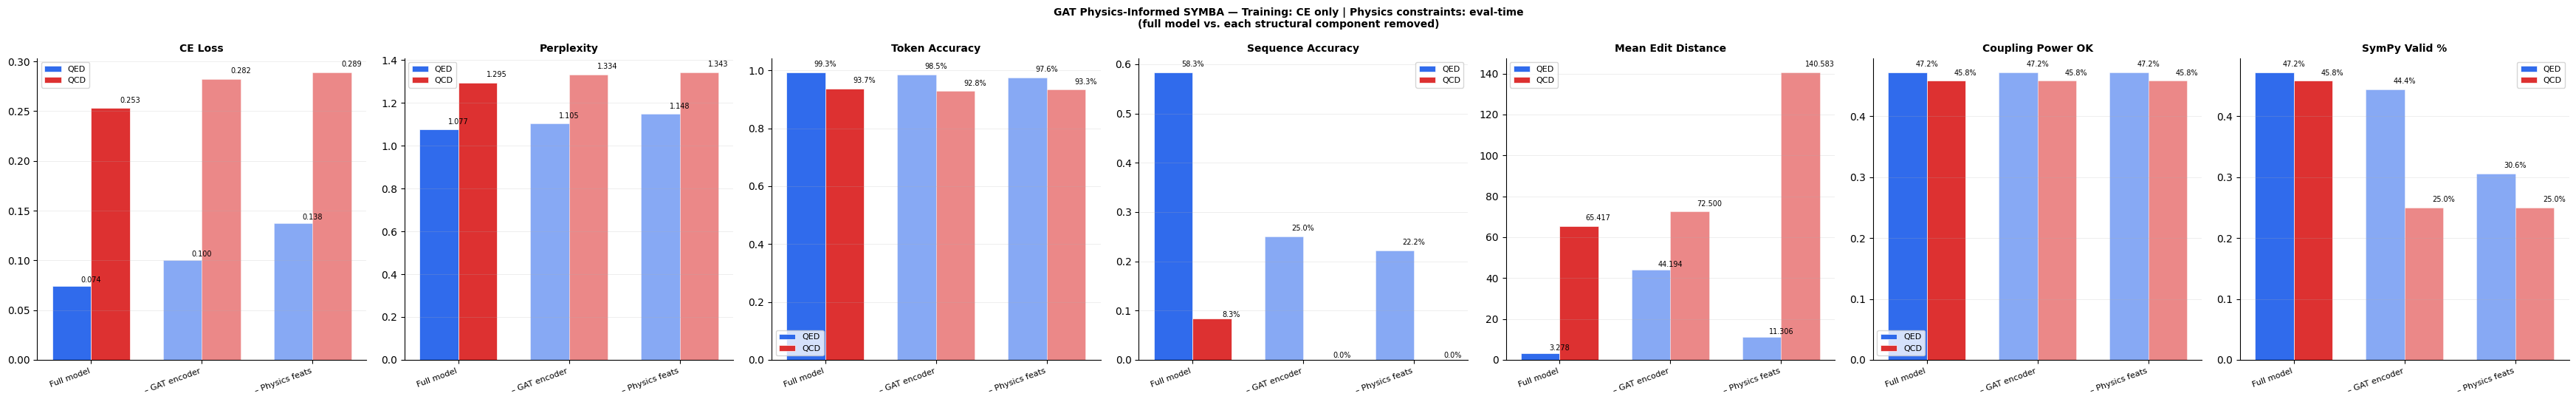

Bar charts saved to ./eval_gat_symba/ablation_bar_charts.png


In [49]:
abl_names = [a for a, _ in ABLATION_CONFIGS]
colors    = {'QED': '#2563EB', 'QCD': '#DC2626'}

plot_metrics = [
    ('ce_loss',     'CE Loss',             False),
    ('ppl',         'Perplexity',          False),
    ('tok_acc',     'Token Accuracy',      True),
    ('seq_acc',     'Sequence Accuracy',   True),
    ('mean_ed',     'Mean Edit Distance',  False),
    ('coupling_ok', 'Coupling Power OK',   True),
]
if 'sympy_valid' in results_df.columns and results_df['sympy_valid'].notna().any():
    plot_metrics.append(('sympy_valid', 'SymPy Valid %', True))

n_metrics = len(plot_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5.5))
if n_metrics == 1: axes = [axes]
fig.suptitle(
    'GAT Physics-Informed SYMBA — Training: CE only | Physics constraints: eval-time\n'
    '(full model vs. each structural component removed)',
    fontsize=10, fontweight='bold'
)

x = np.arange(len(abl_names)); w = 0.35

for ax, (metric, title, higher_is_better) in zip(axes, plot_metrics):
    for li, label in enumerate(LABELS):
        vals = []
        for abl_name in abl_names:
            row = results_df[
                (results_df['ablation'] == abl_name) &
                (results_df['label']    == label)
            ]
            v = row[metric].values[0] if len(row) and pd.notna(row[metric].values[0]) else 0.0
            vals.append(float(v) if v is not None else 0.0)

        bar_alphas = [0.95 if i == 0 else 0.55 for i in range(len(abl_names))]
        for xi, (v, alpha) in enumerate(zip(vals, bar_alphas)):
            ax.bar(xi + li * w, v, w,
                   color=colors[label], alpha=alpha,
                   edgecolor='white', linewidth=0.5,
                   label=label if xi == 0 else '')
            fmt = f'{v*100:.1f}%' if higher_is_better else f'{v:.3f}'
            ax.text(xi + li * w + w/2, v + max(vals) * 0.015,
                    fmt, ha='center', va='bottom', fontsize=7)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels(ABL_DISPLAY_NAMES, fontsize=8, rotation=20, ha='right')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
bar_path = os.path.join(EVAL_DIR, 'ablation_bar_charts.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Bar charts saved to {bar_path}')


## Cell 23 — Training Curves


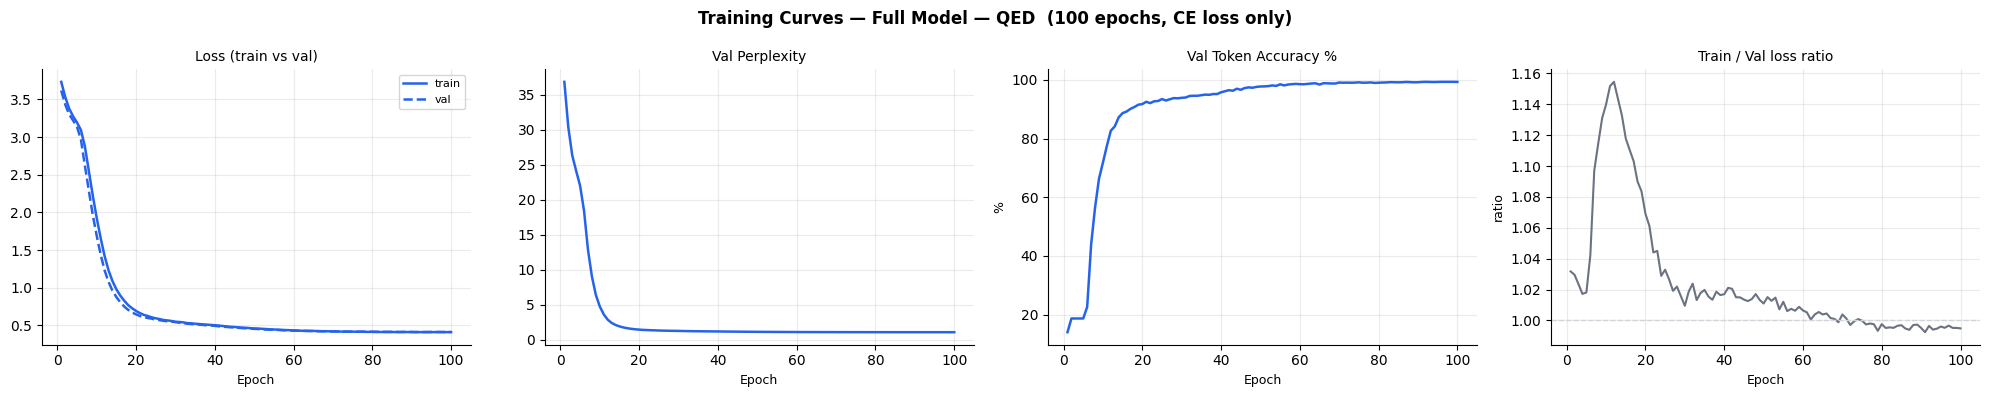

  Saved: ./eval_gat_symba/training_curves_QED.png


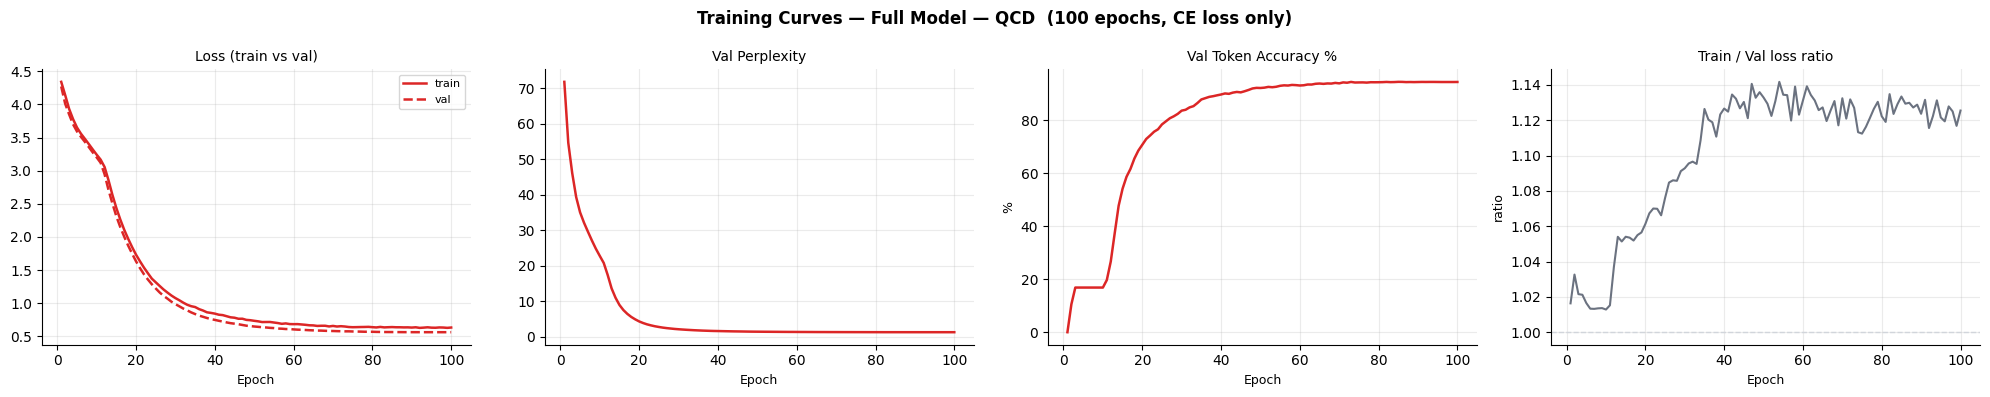

  Saved: ./eval_gat_symba/training_curves_QCD.png


In [50]:
# Training curves — one figure per label
for label in LABELS:
    hist = ALL_HISTORIES.get(f'full_model_{label}')
    if not hist:
        print(f'  [SKIP] No history for {label}')
        continue

    epochs = range(1, len(hist['tr_loss']) + 1)
    color  = '#2563EB' if label == 'QED' else '#DC2626'

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(
        f'Training Curves — Full Model — {label}  ({len(hist["tr_loss"])} epochs, CE loss only)',
        fontsize=12, fontweight='bold'
    )

    # Train vs val loss
    axes[0].plot(epochs, hist['tr_loss'], color=color,    lw=1.8, label='train')
    axes[0].plot(epochs, hist['va_loss'], color=color,    lw=1.8, linestyle='--', label='val')
    axes[0].set_title('Loss (train vs val)', fontsize=10)
    axes[0].legend(fontsize=8)

    # Val perplexity
    axes[1].plot(epochs, hist['va_ppl'], color=color, lw=1.8)
    axes[1].set_title('Val Perplexity', fontsize=10)

    # Val token accuracy
    axes[2].plot(epochs, [v * 100 for v in hist['va_tok_acc']], color=color, lw=1.8)
    axes[2].set_title('Val Token Accuracy %', fontsize=10)
    axes[2].set_ylabel('%', fontsize=9)

    # Train/val loss ratio (training health: ideally stays near 1)
    ratio = [
        tr / va if va > 0 else 1.0
        for tr, va in zip(hist['tr_loss'], hist['va_loss'])
    ]
    axes[3].plot(epochs, ratio, color='#6B7280', lw=1.5)
    axes[3].axhline(1.0, color='#D1D5DB', lw=1, linestyle='--')
    axes[3].set_title('Train / Val loss ratio', fontsize=10)
    axes[3].set_ylabel('ratio', fontsize=9)

    for ax in axes:
        ax.set_xlabel('Epoch', fontsize=9)
        ax.grid(alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    curve_path = os.path.join(EVAL_DIR, f'training_curves_{label}.png')
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {curve_path}')


## Cell 24 — Qualitative Examples: Predictions vs Ground Truth with SymPy Check


In [53]:
def show_qualitative_examples(label, n_examples=5):

    ckpt_path = os.path.join(CKPT_DIR, 'full_model', f'{label}_best.pth')
    if not os.path.exists(ckpt_path):
        print(f'  [MISSING] {ckpt_path}'); return

    tv      = DATASETS[label]['tgt_vocab']
    tgt_max = DATASETS[label]['tgt_max']

    model, _ = build_model(label, FULL_MODEL_FLAGS)
    pkg = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(pkg['model'], strict=False)
    model.eval()

    dl = DataLoader(
        DATASETS[label]['test'], batch_size=1,
        shuffle=False, collate_fn=collate_physics, num_workers=0
    )

    print(f'\n{"─"*80}')
    print(f'  Qualitative Examples — Full Model / {label}')
    print(f'{"─"*80}')

    shown = 0
    with torch.no_grad():
        for src, tgt, graph_b, gf, meta in dl:
            if shown >= n_examples: break
            src = src.to(DEVICE); tgt = tgt.to(DEVICE); gf = gf.to(DEVICE)
            if graph_b is not None: graph_b = graph_b.to(DEVICE)

            ref_toks  = meta['sq_tokens'][0]
            ref_str   = ' '.join(ref_toks[:70]) + ('...' if len(ref_toks) > 70 else '')

            pred_ids = model.greedy_decode(src, graph_b, gf, max_len=tgt_max)[0].tolist()
            if EOS_IDX in pred_ids: pred_ids = pred_ids[1:pred_ids.index(EOS_IDX)]
            pred_toks = tv.decode(pred_ids, include_special=False)
            pred_str  = ' '.join(pred_toks[:70]) + ('...' if len(pred_toks) > 70 else '')

            gf_vec  = gf[0].cpu().tolist()
            is_qcd  = bool(meta['is_qcd'][0])
            sympy_r = validate_squared_amplitude(pred_toks, gf_vec, is_qcd=is_qcd)
            ed      = editdistance.eval(pred_toks, ref_toks)
            exact   = (pred_toks == ref_toks)

            print(f'\n  Example {shown+1}  [is_qcd={is_qcd}]')
            print(f'  Reference : {ref_str}')
            print(f'  Predicted : {pred_str}')
            print(f'  Exact: {"YES " if exact else "NO"}  '
                  f'Edit dist: {ed}  '
                  f'SymPy: {"VALID " if sympy_r["valid"] else "INVALID"}')
            if sympy_r['violations']:
                for v in sympy_r['violations']:
                    print(f'    violation: {v}')
            shown += 1

    model.cpu(); del model; torch.cuda.empty_cache()


# Show examples from the full model for each label
for label in LABELS:
    show_qualitative_examples(label, n_examples=5)



────────────────────────────────────────────────────────────────────────────────
  Qualitative Examples — Full Model / QED
────────────────────────────────────────────────────────────────────────────────

  Example 1  [is_qcd=False]
  Reference : 16 / 81 * e ^ 4 * MOMENTUM_14 * MOMENTUM_24 * ( MOMENTUM_13 + - 1 / 2 * reg_prop ) ^ ( - 2 ) + 32 / 81 * i * e ^ 2 * ( i * e ^ 2 * m_c ^ 2 * ( m_c ^ 2 + 1 / 2 * MOMENTUM_12 ) / ( MOMENTUM_13 + - 1 / 2 * reg_prop...
  Predicted : 32 / 81 * e ^ 4 * MOMENTUM_14 * MOMENTUM_34 * ( MOMENTUM_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) + - 64 / 81 * i * e ^ 2 * ( i * e ^ 2 * m_c ^ 2 * ( m_c ^ 2 + - 1 / 2 * MOMENTUM_13 ) / ( MOMENTUM_12 + 1 / 2 * reg_prop...
  Exact: NO  Edit dist: 18  SymPy: INVALID
    violation: coupling_power=4 (expected 2)

  Example 2  [is_qcd=False]
  Reference : 1 / 324 * e ^ 4 * ( 16 * m_b ^ 2 * m_s ^ 2 + ( - 8 ) * m_b ^ 2 * MOMENTUM_13 + 8 * MOMENTUM_14 * MOMENTUM_23 + ( - 8 ) * m_s ^ 2 * MOMENTUM_24 + 8 * MOMENTUM_12 * MOMENTUM_34 ) 

## Cell 25 — Save All Results to Disk


In [52]:
# Save the full results package
results_package = {
    'results_df'      : results_df.to_dict('records'),
    'all_histories'   : {k: v for k, v in ALL_HISTORIES.items() if v is not None},
    'all_ckpts'       : ALL_CKPTS,
    'ablation_configs': ABLATION_CONFIGS,
    'full_model_flags': FULL_MODEL_FLAGS,
    'cfg'             : CFG,
    'labels'          : LABELS,
}
pkg_path = os.path.join(EVAL_DIR, 'full_results_package.pkl')
with open(pkg_path, 'wb') as f:
    pickle.dump(results_package, f)
print(f'Full results saved to: {pkg_path}')

# ── Final summary ──────────────────────────────────────────────────────────
print('\n' + '='*120)
print('  FINAL RESULTS — GAT Physics-Informed SYMBA')
print('  Training: CrossEntropyLoss only | Physics constraints: post-hoc SymPy evaluation')
print('='*120)
hdr = (f'  {"Config":<18}  {"Label":<5}  {"CE":>8}  {"PPL":>8}  '
       f'{"TokAcc":>8}  {"SeqAcc":>8}  {"EditD":>7}  '
       f'{"Coupl%":>8}  {"Color%":>8}  {"SymPy%":>8}  {"Exact":>8}')
print(hdr)
print(f'  {"-"*115}')
for res in ALL_RESULTS:
    coup = f'{res["coupling_ok"]*100:.1f}%' if res.get('coupling_ok') is not None else 'N/A'
    col  = f'{res["color_ok"]*100:.1f}%'    if res.get('color_ok')    is not None else 'N/A'
    sv   = f'{res["sympy_valid"]*100:.1f}%' if res.get('sympy_valid') is not None else 'N/A'
    print(
        f'  {res["ablation"]:<18}  {res["label"]:<5}  '
        f'{res["ce_loss"]:8.4f}  {res["ppl"]:8.4f}  '
        f'{res["tok_acc"]*100:7.2f}%  {res["seq_acc"]*100:7.2f}%  '
        f'{res["mean_ed"]:7.3f}  '
        f'{coup:>8}  {col:>8}  {sv:>8}  {res["exact_str"]:>8}'
    )
print('='*120)
print(f'\nOutputs   : {EVAL_DIR}/')
print(f'Checkpoint: {CKPT_DIR}/full_model/{{QED,QCD}}_best.pth')


Full results saved to: ./eval_gat_symba/full_results_package.pkl

  FINAL RESULTS — GAT Physics-Informed SYMBA
  Training: CrossEntropyLoss only | Physics constraints: post-hoc SymPy evaluation
  Config              Label        CE       PPL    TokAcc    SeqAcc    EditD    Coupl%    Color%    SymPy%     Exact
  -------------------------------------------------------------------------------------------------------------------
  full_model          QED      0.0742    1.0767    99.28%    58.33%    3.278     47.2%       N/A     47.2%     21/36
  full_model          QCD      0.2530    1.2949    93.67%     8.33%   65.417     45.8%     62.5%     45.8%      2/24
  no_gat              QED      0.1004    1.1054    98.51%    25.00%   44.194     47.2%       N/A     44.4%      9/36
  no_gat              QCD      0.2825    1.3338    92.78%     0.00%   72.500     45.8%     62.5%     25.0%      0/24
  no_phys_feats       QED      0.1377    1.1480    97.61%    22.22%   11.306     47.2%       N/A     30